In [45]:
import importlib

import matplotlib.pyplot as plt

import components.other_utilities.user_logger

importlib.reload(components.other_utilities.user_logger)
from components.other_utilities.user_logger import get_unified_data_tables
importlib.reload(components.other_utilities.user_logger)
from components.other_utilities.user_logger import plot_all_metrics
from experiments.run_sim_script.run_sim import proto_choices

In [46]:
report_data=get_unified_data_tables('_dev_debug_test', 5)

KeyboardInterrupt: 

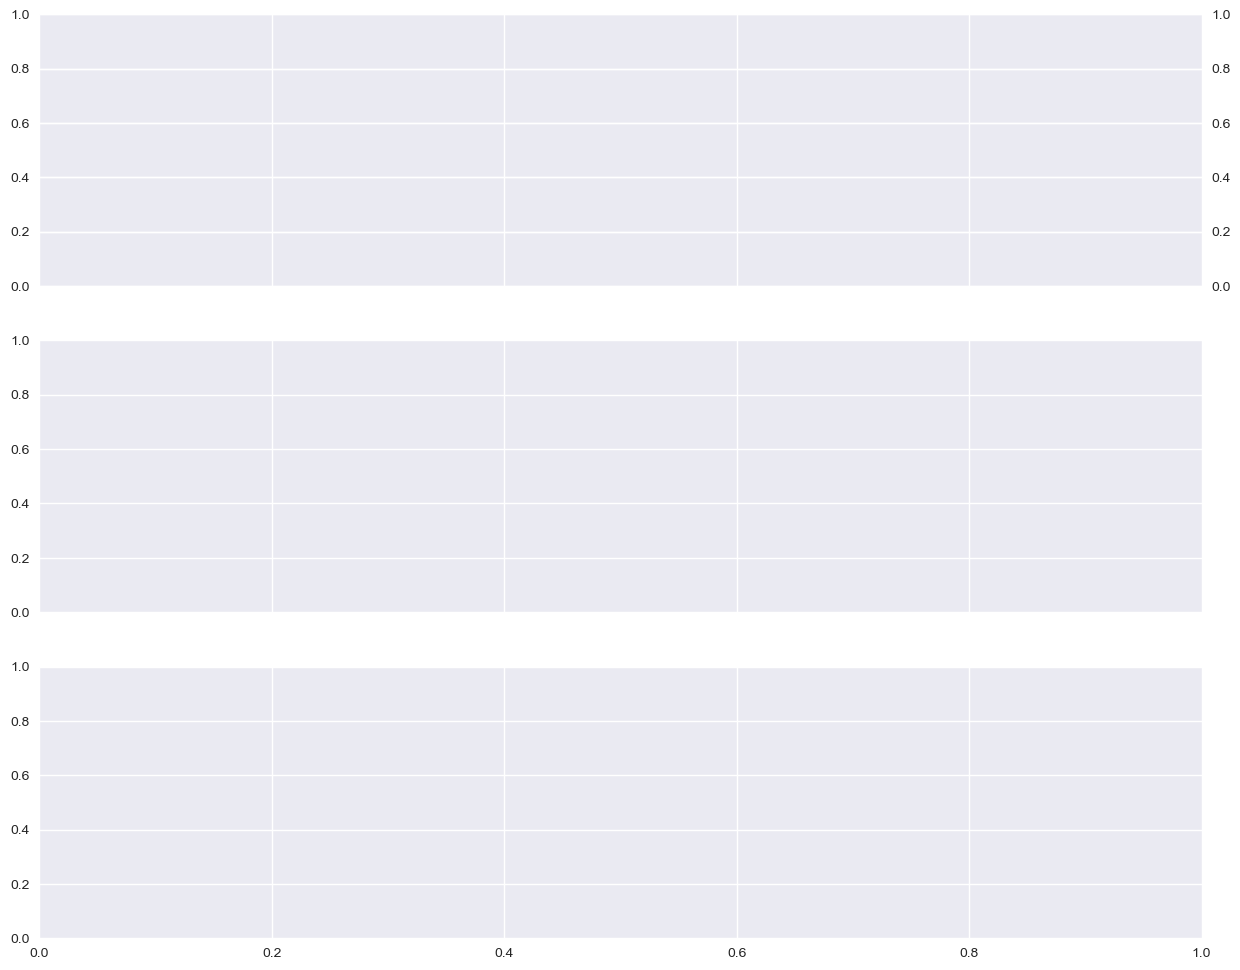

In [49]:
plot_all_metrics(*report_data)

In [ ]:
import os
import pandas as pd
from experiments.run_sim_script.run_sim import proto_choices

proto_choices+=['_dev_debug_test']

broadcast_entire_stats={}
global_metric_before_round= {}
for kk in proto_choices:
    for temp in ['_no_global_quant', '']:
        k=kk+temp
        path_folder = os.path.join(r'reports of runs', k)
        if not os.path.isdir(path_folder):
            continue
        temp = pd.read_csv(os.path.join(path_folder, '_global_metrics_before_round_start.csv'))
        global_metric_before_round[k] = temp

        fix_tensor = lambda x: eval(x[6:]) #if type(x) is str else x
        for l in ['val_auc', 'train_auc']:
            global_metric_before_round[k][l]=global_metric_before_round[k][l].apply(fix_tensor)

        # meow -----------------
        round_count = len(global_metric_before_round[k])-1
        file_path = os.path.join(path_folder, '_broadcast_protocol_stats', 'wz.csv')
        broadcast_entire_stats[k] = pd.read_csv(file_path)

        temp = broadcast_entire_stats[k].agent_id!=0
        broadcast_entire_stats[k].loc[temp, 'mbytes_sent_for_aggre'] = 0.0
        temp=lambda i: (broadcast_entire_stats[k]['round_id']==i).values
        broadcast_entire_stats[k] = {
            kkkk: [broadcast_entire_stats[k][kkkk][temp(i)].values for i in range(round_count)]
            for kkkk in broadcast_entire_stats[k].columns
        }

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle, islice

total_params = 11_191_262
round_key = 'round_id'

# --- Build a big pool of distinguishable colors ---
# Start with color-blind friendly Tableau palettes and concatenate
def get_long_color_list():
    c = []
    for name in ['tab10', 'tab20', 'tab20b', 'tab20c']:
        c.extend(plt.cm.get_cmap(name).colors)
    # Remove near-duplicates by rounding (simple de-dupe)
    seen = set()
    uniq = []
    for r,g,b in c:
        key = (round(r,2), round(g,2), round(b,2))
        if key not in seen:
            seen.add(key)
            uniq.append((r,g,b))
    return uniq

all_colors = get_long_color_list()

# Prepare marker & linestyle cycles to help distinguish beyond color
marker_cycle = cycle(['o','s','^','v','D','P','X','*','<','>'])
linestyle_cycle_metric = cycle(['-'])          # metrics: solid
linestyle_cycle_br = cycle(['--'])             # bit-rate: dashed

keys_list = list(global_metric_before_round.keys())

# Assign each k a unique color + marker (repeat if more keys than options)
key_to_color = {k: all_colors[i % len(all_colors)] for i, k in enumerate(keys_list)}
key_to_marker = {k: next(marker_cycle) for k in keys_list}  # consumes n markers in order

for metric in ['val_auc', 'train_loss', 'train_auc', 'val_loss']:
    fig, ax = plt.subplots(figsize=(18, 6))
    ax2 = ax.twinx()

    metric_lines = []
    br_lines = []

    # Left axis: metric
    for k in keys_list:
        temp = global_metric_before_round[k]
        x = temp[round_key].values
        y = temp[metric].values
        (line,) = ax.plot(
            x, y,
            label=k,
            color=key_to_color[k],
            linestyle=next(linestyle_cycle_metric),
            marker=key_to_marker[k],
            markersize=3,
            linewidth=1.6
        )
        metric_lines.append(line)

    ax.set_title(metric)
    ax.set_xlabel('round')
    ax.set_ylabel(metric)
    ax.grid(True, which='both', alpha=0.3)
    if metric in ['val_auc', 'train_auc']:
        ax.set_ylim(0.6, 1.01)

    # Right axis: bit rate (reuse SAME color/marker, use dashed line)
    for k in keys_list:
        total_mb = 0
        for k_transfer in ['mbytes_recived', 'mbytes_sent_for_aggre', 'mbytes_sent_to_worker']:
            if k_transfer in broadcast_entire_stats[k]:
                total_mb += np.sum(broadcast_entire_stats[k][k_transfer], axis=1)

        bit_rate = (total_mb * 1024 * 1024 * 8) / total_params
        # bit_rate = np.mean(broadcast_entire_stats[k]['mape%'], axis=1)

        x = global_metric_before_round[k][round_key].values[:-1]

        (br_line,) = ax2.plot(
            x, bit_rate,
            # label=f'BR - {k}',
            color=key_to_color[k],      # same color
            linestyle='--',             # different style
            marker=key_to_marker[k],    # same marker
            markersize=3,
            linewidth=1.2,
            alpha=0.9
        )
        # br_lines.append(br_line)

    ax2.set_ylabel('Bit Rate (bits/parameter)')
    # ax2.set_ylabel('MSPE%')
    ax2.tick_params(axis='y')
    ax2.grid(False)

    # Combined legend, split in columns to avoid mega-tall legends
    lines = metric_lines + br_lines
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', ncol=2, frameon=True)

    plt.tight_layout()
    plt.show()


In [ ]:
for p_name in proto_choices:
    print('\n\n\n', p_name)
    try:
        report_data=get_unified_data_tables(p_name, 5)
        plot_all_metrics(*report_data)
    except:
        pass




 no_proto



 all_out



 balanced_hybrid



 hybrid



 no_proto_only_global



 simple
